# Sphere movement analysis (w/ discrete time interval selecction)

## Libraries

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile

from scipy import ndimage as ndi
from scipy.stats import pearsonr

from skimage import filters, measure, morphology

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams["figure.figsize"] = (7, 6)
plt.rcParams["image.cmap"] = "gray"

## File search on local storage

In [2]:
from pathlib import Path
import tifffile

# =========================
# DIRECT TIFF FILE PATH
# =========================
STACK_PATH = Path(
    #r"C:\Users\super\OneDrive\Desktop\Desktop1\20260210_Control4_Sphere_in_Vehicle_Fluo4_50nM_NAOH_Ca2+_5uM_a\20260210_Control4_Sphere_in_Vehicle_Fluo4_50nM_NAOH_Ca2+_5uM_a_bg01.ome.tif"
    r"C:\Users\super\OneDrive\Desktop\Desktop1\20260210_Control2_Sphere_in_Vehicle_no_Fluos_a\20260210_Control2_Sphere_in_Vehicle_no_Fluos_a_bg01.ome.tif"
)

# =========================
# BASIC PATH CHECK
# =========================
print("Selected path:")
print(STACK_PATH)

print("\nPath exists:", STACK_PATH.exists())
print("Is file:", STACK_PATH.is_file())
print("Suffixes:", STACK_PATH.suffixes)

if not STACK_PATH.exists():
    raise FileNotFoundError(f"File not found:\n{STACK_PATH}")

if not STACK_PATH.is_file():
    raise FileNotFoundError(f"The path exists, but it is not a file:\n{STACK_PATH}")

# =========================
# LOAD TIFF STACK
# =========================
try:
    stack = tifffile.memmap(STACK_PATH)
    print("\nLoaded with tifffile.memmap()")
except Exception:
    stack = tifffile.imread(STACK_PATH)
    print("\nLoaded with tifffile.imread()")

print("Stack shape:", stack.shape)
print("Stack dtype:", stack.dtype)

# Keep this variable name for the next notebook sections
selected_stack_path = STACK_PATH

Selected path:
C:\Users\super\OneDrive\Desktop\Desktop1\20260210_Control2_Sphere_in_Vehicle_no_Fluos_a\20260210_Control2_Sphere_in_Vehicle_no_Fluos_a_bg01.ome.tif

Path exists: True
Is file: True
Suffixes: ['.ome', '.tif']

Loaded with tifffile.memmap()
Stack shape: (48000, 64, 64)
Stack dtype: uint16


## Global variables

In [3]:
# =========================
# GLOBAL SETTINGS
# =========================
EXPECTED_TOTAL_FRAMES = 48000
EXPECTED_HEIGHT = 64
EXPECTED_WIDTH = 64

MASK_MEAN_FRAMES = 5000
MASK_START_FRAME = 0

THRESHOLD_ADU = 250
GAUSSIAN_SIGMA = 1.0
MASK_DILATION_ITERS = 1
MIN_MASK_AREA_PX = 9

COM_CHUNK_SIZE = 4000
N_ITERATIONS = 100
BASE_RANDOM_SEED = 12345

SHOW_PIXEL_GRID = False
MAX_POINTS_TO_PLOT = 4000

#ANALYSIS_INTERVALS = [(23000, 24000)]

# Analyze the full stack by default
ANALYSIS_INTERVALS = [(0, 48000)]

# Example alternatives:
# ANALYSIS_INTERVALS = [(5000, 15000)]
# ANALYSIS_INTERVALS = [(0, 5000), (12000, 18000), (30000, 36000)]

# =========================
# MASK SETTINGS
# =========================
USE_FULL_STACK_FOR_MASK = True

MASK_START_FRAME = 0
MASK_MEAN_FRAMES = 5000
MASK_PROJECTION_CHUNK_SIZE = 4000

# =========================
# INTERVAL HANDLING
# =========================
def validate_analysis_intervals(intervals, total_frames):
    if intervals is None or len(intervals) == 0:
        return [(0, total_frames)]

    validated_intervals = []

    for start_frame, end_frame in intervals:
        start_frame = int(start_frame)
        end_frame = int(end_frame)

        if start_frame < 0 or end_frame < 0:
            raise ValueError("Frame interval values must be non-negative.")

        if end_frame <= start_frame:
            raise ValueError(f"Invalid interval: ({start_frame}, {end_frame})")

        if end_frame > total_frames:
            raise ValueError(
                f"Interval ({start_frame}, {end_frame}) exceeds total frames ({total_frames})."
            )

        validated_intervals.append((start_frame, end_frame))

    return validated_intervals


def count_total_selected_frames(intervals):
    return sum(end_frame - start_frame for start_frame, end_frame in intervals)


# =========================
# STACK LOADING
# =========================
def open_tiff_stack(stack_path):
    stack_path = Path(stack_path)

    try:
        stack = tifffile.memmap(stack_path)
    except Exception:
        stack = tifffile.imread(stack_path)

    if stack.ndim != 3:
        raise ValueError(
            f"Expected a 3D TIFF stack with shape (frames, height, width), but got shape {stack.shape}"
        )

    return stack


def validate_stack_shape(stack, expected_height=None, expected_width=None, expected_frames=None):
    n_frames, height, width = stack.shape

    print(f"Stack shape detected: frames={n_frames}, height={height}, width={width}")

    if expected_height is not None and height != expected_height:
        print(f"Warning: detected height ({height}) differs from expected height ({expected_height})")

    if expected_width is not None and width != expected_width:
        print(f"Warning: detected width ({width}) differs from expected width ({expected_width})")

    if expected_frames is not None and n_frames != expected_frames:
        print(f"Warning: detected frames ({n_frames}) differs from expected frames ({expected_frames})")

    return n_frames, height, width


# =========================
# PIXEL MESH
# =========================
def build_pixel_mesh(height, width):
    y_mesh, x_mesh = np.indices((height, width), dtype=np.float64)
    return y_mesh, x_mesh


# =========================
# MEAN PROJECTION
# =========================
def compute_mean_projection(
    stack,
    use_full_stack=True,
    start_frame=0,
    n_frames=5000,
    chunk_size=4000,
):
    total_frames = stack.shape[0]

    if use_full_stack:
        frame_ranges = [(0, total_frames)]
        n_frames_used = total_frames
    else:
        end_frame = min(start_frame + n_frames, total_frames)
        frame_ranges = [(start_frame, end_frame)]
        n_frames_used = end_frame - start_frame

    if n_frames_used <= 0:
        raise ValueError("The number of frames used for the mean projection must be greater than zero.")

    accumulator = np.zeros(stack.shape[1:], dtype=np.float64)

    for range_start, range_end in frame_ranges:
        for chunk_start in range(range_start, range_end, chunk_size):
            chunk_end = min(chunk_start + chunk_size, range_end)
            chunk = np.asarray(stack[chunk_start:chunk_end], dtype=np.float64)
            accumulator += np.sum(chunk, axis=0)

    mean_projection = accumulator / n_frames_used
    return mean_projection


# =========================
# MASK GENERATION
# =========================
def generate_effective_mask(
    mean_projection,
    threshold_adu=130,
    gaussian_sigma=1.0,
    dilation_iters=1,
    min_mask_area_px=9,
):
    smoothed_projection = filters.gaussian(
        mean_projection.astype(np.float64),
        sigma=gaussian_sigma,
        preserve_range=True,
    )

    threshold_mask = smoothed_projection >= threshold_adu

    if not np.any(threshold_mask):
        raise ValueError(
            "No pixels survived the threshold. Lower THRESHOLD_ADU or inspect the mean projection."
        )

    seed_position = np.unravel_index(np.argmax(smoothed_projection), smoothed_projection.shape)

    labeled_mask = measure.label(threshold_mask, connectivity=2)
    seed_label = labeled_mask[seed_position]

    if seed_label == 0:
        raise ValueError("The seed pixel does not belong to a valid connected component.")

    effective_mask = labeled_mask == seed_label
    effective_mask = ndi.binary_fill_holes(effective_mask)

    effective_mask = morphology.remove_small_objects(
        effective_mask.astype(bool),
        min_size=min_mask_area_px,
    )

    if dilation_iters > 0:
        effective_mask = ndi.binary_dilation(effective_mask, iterations=dilation_iters)

    effective_mask = effective_mask.astype(bool)

    if not np.any(effective_mask):
        raise ValueError("The final effective mask is empty after post-processing.")

    return {
        "smoothed_projection": smoothed_projection,
        "threshold_mask": threshold_mask,
        "effective_mask": effective_mask,
        "seed_position": seed_position,
    }


# =========================
# MASK QC
# =========================
def add_pixel_grid(ax, height, width, alpha=0.15, linewidth=0.3):
    for x in range(width + 1):
        ax.axvline(x - 0.5, color="white", alpha=alpha, linewidth=linewidth)
    for y in range(height + 1):
        ax.axhline(y - 0.5, color="white", alpha=alpha, linewidth=linewidth)


def plot_mask_qc(
    mean_projection,
    smoothed_projection,
    threshold_mask,
    effective_mask,
    seed_position,
    show_pixel_grid=False,
):
    height, width = mean_projection.shape

    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

    axes[0].imshow(mean_projection)
    axes[0].scatter(seed_position[1], seed_position[0], s=40, marker="x")
    axes[0].set_title("Mean projection")
    axes[0].set_axis_off()

    axes[1].imshow(smoothed_projection)
    axes[1].scatter(seed_position[1], seed_position[0], s=40, marker="x")
    axes[1].set_title("Smoothed projection")
    axes[1].set_axis_off()

    axes[2].imshow(threshold_mask)
    axes[2].scatter(seed_position[1], seed_position[0], s=40, marker="x")
    axes[2].set_title("Threshold mask")
    axes[2].set_axis_off()

    axes[3].imshow(mean_projection)
    axes[3].contour(effective_mask.astype(np.uint8), levels=[0.5], linewidths=1.2)
    axes[3].scatter(seed_position[1], seed_position[0], s=40, marker="x")
    axes[3].set_title("Effective mask overlay")
    axes[3].set_axis_off()

    if show_pixel_grid:
        for ax in axes:
            add_pixel_grid(ax, height, width)

    plt.tight_layout()
    plt.show()


# =========================
# RANDOM CLASS ASSIGNMENT
# =========================
def assign_random_classes_from_mask(effective_mask, random_seed=None):
    rng = np.random.default_rng(random_seed)

    mask_y, mask_x = np.nonzero(effective_mask)
    n_pixels = mask_y.size

    pixel_indices = np.arange(n_pixels)
    rng.shuffle(pixel_indices)

    split_index = n_pixels // 2

    class_a_indices = pixel_indices[:split_index]
    class_b_indices = pixel_indices[split_index:]

    class_a_selector = np.zeros(n_pixels, dtype=bool)
    class_b_selector = np.zeros(n_pixels, dtype=bool)

    class_a_selector[class_a_indices] = True
    class_b_selector[class_b_indices] = True

    class_a_mask = np.zeros_like(effective_mask, dtype=bool)
    class_b_mask = np.zeros_like(effective_mask, dtype=bool)

    class_a_mask[mask_y[class_a_selector], mask_x[class_a_selector]] = True
    class_b_mask[mask_y[class_b_selector], mask_x[class_b_selector]] = True

    return {
        "mask_y": mask_y,
        "mask_x": mask_x,
        "class_a_selector": class_a_selector,
        "class_b_selector": class_b_selector,
        "class_a_mask": class_a_mask,
        "class_b_mask": class_b_mask,
        "n_pixels_total": n_pixels,
        "n_pixels_class_a": int(class_a_selector.sum()),
        "n_pixels_class_b": int(class_b_selector.sum()),
    }


def plot_class_assignment_qc(mean_projection, effective_mask, class_a_mask, class_b_mask):
    rgb_overlay = np.zeros((*effective_mask.shape, 3), dtype=np.float32)

    rgb_overlay[..., 0] = class_a_mask.astype(np.float32)
    rgb_overlay[..., 1] = class_b_mask.astype(np.float32)
    rgb_overlay[..., 2] = 0.0

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

    axes[0].imshow(mean_projection)
    axes[0].set_title("Mean projection")
    axes[0].set_axis_off()

    axes[1].imshow(effective_mask)
    axes[1].set_title("Effective mask")
    axes[1].set_axis_off()

    axes[2].imshow(mean_projection, alpha=0.55)
    axes[2].imshow(rgb_overlay, alpha=0.65)
    axes[2].set_title("Class A/B assignment")
    axes[2].set_axis_off()

    plt.tight_layout()
    plt.show()


# =========================
# MASKED TRACE EXTRACTION
# =========================
def extract_masked_pixel_traces(
    stack,
    effective_mask,
    analysis_intervals=None,
    chunk_size=4000,
    output_dtype=np.float32,
):
    mask_y, mask_x = np.nonzero(effective_mask)

    total_frames = stack.shape[0]
    validated_intervals = validate_analysis_intervals(analysis_intervals, total_frames)
    total_selected_frames = count_total_selected_frames(validated_intervals)

    n_pixels = mask_y.size
    masked_traces = np.empty((total_selected_frames, n_pixels), dtype=output_dtype)
    frame_indices = np.empty(total_selected_frames, dtype=int)

    write_start = 0

    for start_frame, end_frame in validated_intervals:
        interval_length = end_frame - start_frame
        frame_indices[write_start:write_start + interval_length] = np.arange(start_frame, end_frame)

        local_write_start = write_start

        for chunk_start in range(start_frame, end_frame, chunk_size):
            chunk_end = min(chunk_start + chunk_size, end_frame)
            chunk = np.asarray(stack[chunk_start:chunk_end], dtype=output_dtype)

            local_chunk_start = local_write_start + (chunk_start - start_frame)
            local_chunk_end = local_chunk_start + (chunk_end - chunk_start)

            masked_traces[local_chunk_start:local_chunk_end] = chunk[:, mask_y, mask_x]

        write_start += interval_length

    return masked_traces, mask_y.astype(np.float64), mask_x.astype(np.float64), frame_indices


# =========================
# CENTER OF MASS
# =========================
def compute_com_series_from_traces(masked_traces, mask_x, mask_y, class_selector, frame_indices=None):
    class_traces = masked_traces[:, class_selector]
    class_x = mask_x[class_selector]
    class_y = mask_y[class_selector]

    intensity_sum = np.sum(class_traces, axis=1)
    valid = intensity_sum > 0

    x_com = np.full(masked_traces.shape[0], np.nan, dtype=np.float64)
    y_com = np.full(masked_traces.shape[0], np.nan, dtype=np.float64)

    if np.any(valid):
        x_com[valid] = (class_traces[valid] @ class_x) / intensity_sum[valid]
        y_com[valid] = (class_traces[valid] @ class_y) / intensity_sum[valid]

    if frame_indices is None:
        frame_indices = np.arange(masked_traces.shape[0], dtype=int)

    com_table = pd.DataFrame(
        {
            "frame": frame_indices,
            "x_com": x_com,
            "y_com": y_com,
            "intensity_sum": intensity_sum,
        }
    )

    return com_table


# =========================
# CORRELATION
# =========================
def safe_pearson_correlation(series_a, series_b):
    series_a = np.asarray(series_a, dtype=np.float64)
    series_b = np.asarray(series_b, dtype=np.float64)

    valid = np.isfinite(series_a) & np.isfinite(series_b)

    if np.sum(valid) < 3:
        return np.nan

    a = series_a[valid]
    b = series_b[valid]

    if np.std(a) == 0 or np.std(b) == 0:
        return np.nan

    return pearsonr(a, b)[0]


def compute_com_correlation_summary(com_a, com_b):
    corr_x = safe_pearson_correlation(com_a["x_com"].values, com_b["x_com"].values)
    corr_y = safe_pearson_correlation(com_a["y_com"].values, com_b["y_com"].values)
    corr_mean_xy = np.nanmean([corr_x, corr_y])

    summary = {
        "corr_x": corr_x,
        "corr_y": corr_y,
        "corr_mean_xy": corr_mean_xy,
    }

    return summary


# =========================
# COM QC PLOT
# =========================
def build_segmented_plot_arrays(frame_values, signal_values):
    frame_values = np.asarray(frame_values)
    signal_values = np.asarray(signal_values, dtype=np.float64)

    x_plot = []
    y_plot = []

    for index in range(len(frame_values)):
        x_plot.append(frame_values[index])
        y_plot.append(signal_values[index])

        if index < len(frame_values) - 1:
            if frame_values[index + 1] - frame_values[index] > 1:
                x_plot.append(np.nan)
                y_plot.append(np.nan)

    return np.asarray(x_plot, dtype=np.float64), np.asarray(y_plot, dtype=np.float64)


def plot_com_series(com_a, com_b, analysis_intervals=None, max_points_to_plot=4000):
    """
    Plot COM time series using the real analysis intervals.
    This avoids artificial line breaks introduced by downsampling.
    """
    if analysis_intervals is None:
        analysis_intervals = [(int(com_a["frame"].min()), int(com_a["frame"].max()) + 1)]

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    total_selected_frames = len(com_a)
    points_per_interval = max(50, max_points_to_plot // max(1, len(analysis_intervals)))

    for interval_index, (start_frame, end_frame) in enumerate(analysis_intervals):
        mask_a = (com_a["frame"] >= start_frame) & (com_a["frame"] < end_frame)
        mask_b = (com_b["frame"] >= start_frame) & (com_b["frame"] < end_frame)

        com_a_interval = com_a.loc[mask_a].copy()
        com_b_interval = com_b.loc[mask_b].copy()

        if len(com_a_interval) == 0 or len(com_b_interval) == 0:
            continue

        # Downsample only within each true interval
        if len(com_a_interval) > points_per_interval:
            sampled_indices = np.linspace(
                0,
                len(com_a_interval) - 1,
                points_per_interval
            ).astype(int)

            com_a_interval = com_a_interval.iloc[sampled_indices]
            com_b_interval = com_b_interval.iloc[sampled_indices]

        label_a = "Class A" if interval_index == 0 else None
        label_b = "Class B" if interval_index == 0 else None

        axes[0].plot(
            com_a_interval["frame"].values,
            com_a_interval["x_com"].values,
            linewidth=1.0,
            label=label_a,
        )
        axes[0].plot(
            com_b_interval["frame"].values,
            com_b_interval["x_com"].values,
            linewidth=1.0,
            label=label_b,
        )

        axes[1].plot(
            com_a_interval["frame"].values,
            com_a_interval["y_com"].values,
            linewidth=1.0,
            label=label_a,
        )
        axes[1].plot(
            com_b_interval["frame"].values,
            com_b_interval["y_com"].values,
            linewidth=1.0,
            label=label_b,
        )

    axes[0].set_ylabel("X COM (px)")
    axes[0].set_title("X center of mass vs time")
    axes[0].legend()

    axes[1].set_xlabel("Frame")
    axes[1].set_ylabel("Y COM (px)")
    axes[1].set_title("Y center of mass vs time")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


# =========================
# ITERATIVE ANALYSIS
# =========================
def run_com_correlation_iterations(
    masked_traces,
    mask_x,
    mask_y,
    frame_indices,
    n_iterations=100,
    base_seed=12345,
    report_every=10,
):
    n_pixels = mask_x.size
    results = []

    for iteration_index in range(n_iterations):
        current_seed = base_seed + iteration_index

        pixel_indices = np.arange(n_pixels)
        rng = np.random.default_rng(current_seed)
        rng.shuffle(pixel_indices)

        split_index = n_pixels // 2

        class_a_selector = np.zeros(n_pixels, dtype=bool)
        class_b_selector = np.zeros(n_pixels, dtype=bool)

        class_a_selector[pixel_indices[:split_index]] = True
        class_b_selector[pixel_indices[split_index:]] = True

        com_a = compute_com_series_from_traces(
            masked_traces=masked_traces,
            mask_x=mask_x,
            mask_y=mask_y,
            class_selector=class_a_selector,
            frame_indices=frame_indices,
        )

        com_b = compute_com_series_from_traces(
            masked_traces=masked_traces,
            mask_x=mask_x,
            mask_y=mask_y,
            class_selector=class_b_selector,
            frame_indices=frame_indices,
        )

        corr_summary = compute_com_correlation_summary(com_a, com_b)

        results.append(
            {
                "iteration": iteration_index + 1,
                "seed": current_seed,
                "n_pixels_class_a": int(class_a_selector.sum()),
                "n_pixels_class_b": int(class_b_selector.sum()),
                "corr_x": corr_summary["corr_x"],
                "corr_y": corr_summary["corr_y"],
                "corr_mean_xy": corr_summary["corr_mean_xy"],
            }
        )

        if (iteration_index + 1) % report_every == 0 or iteration_index == 0:
            print(f"Completed iteration {iteration_index + 1}/{n_iterations}")

    results_df = pd.DataFrame(results)
    return results_df

## Pixel mesh, mean projection, mask generation, and QC

Stack shape detected: frames=48000, height=64, width=64
Pixel mesh shape: (64, 64)
Mask projection mode: full stack
Frames used for mask projection: 0 to 47999
Effective mask pixels: 163
Seed position: (np.int64(51), np.int64(29))


C:\Users\super\AppData\Local\Temp\ipykernel_3756\2893476586.py:187: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  effective_mask = morphology.remove_small_objects(


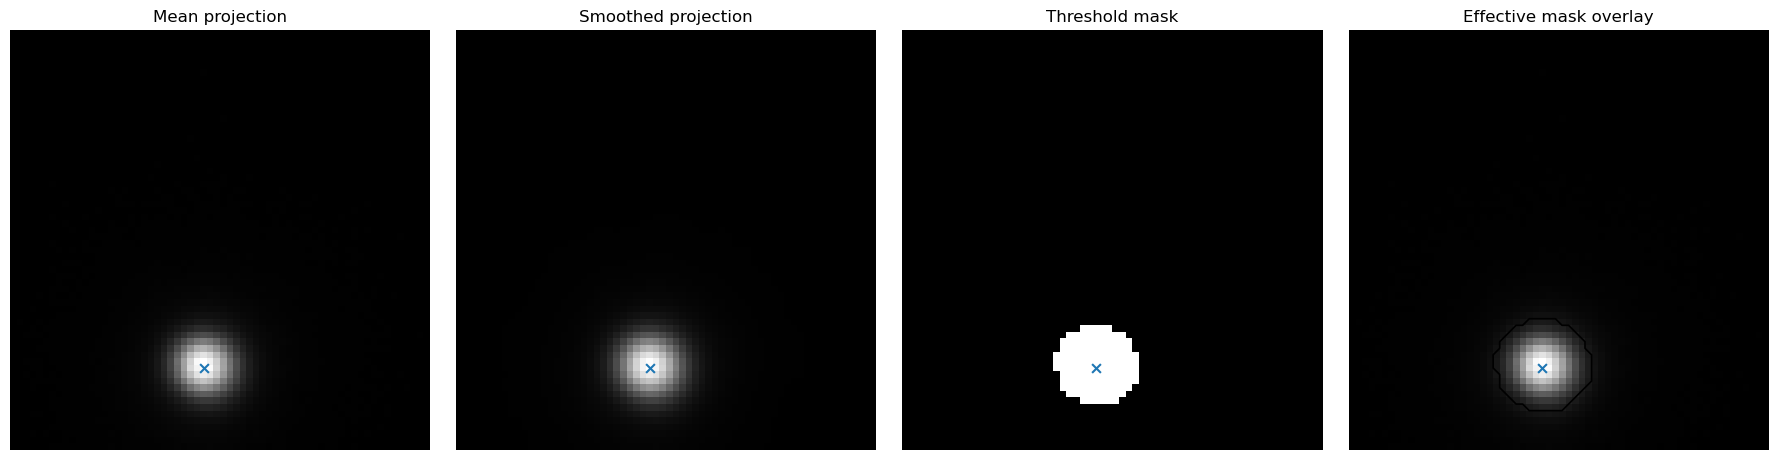

In [4]:
# =========================
# STACK LOAD
# =========================
stack = open_tiff_stack(selected_stack_path)
n_frames, height, width = validate_stack_shape(
    stack,
    expected_height=EXPECTED_HEIGHT,
    expected_width=EXPECTED_WIDTH,
    expected_frames=EXPECTED_TOTAL_FRAMES,
)

# =========================
# PIXEL MESH
# =========================
y_mesh, x_mesh = build_pixel_mesh(height, width)

print(f"Pixel mesh shape: {y_mesh.shape}")

# =========================
# MEAN PROJECTION FOR MASK
# =========================
mean_projection = compute_mean_projection(
    stack=stack,
    use_full_stack=USE_FULL_STACK_FOR_MASK,
    start_frame=MASK_START_FRAME,
    n_frames=MASK_MEAN_FRAMES,
    chunk_size=MASK_PROJECTION_CHUNK_SIZE,
)

if USE_FULL_STACK_FOR_MASK:
    print("Mask projection mode: full stack")
    print(f"Frames used for mask projection: 0 to {n_frames - 1}")
else:
    print("Mask projection mode: partial stack")
    print(f"Frames used for mask projection: {MASK_START_FRAME} to {min(MASK_START_FRAME + MASK_MEAN_FRAMES, n_frames) - 1}")

# =========================
# MASK GENERATION
# =========================
mask_results = generate_effective_mask(
    mean_projection=mean_projection,
    threshold_adu=THRESHOLD_ADU,
    gaussian_sigma=GAUSSIAN_SIGMA,
    dilation_iters=MASK_DILATION_ITERS,
    min_mask_area_px=MIN_MASK_AREA_PX,
)

smoothed_projection = mask_results["smoothed_projection"]
threshold_mask = mask_results["threshold_mask"]
effective_mask = mask_results["effective_mask"]
seed_position = mask_results["seed_position"]

print(f"Effective mask pixels: {np.sum(effective_mask)}")
print(f"Seed position: {seed_position}")

# =========================
# QC
# =========================
plot_mask_qc(
    mean_projection=mean_projection,
    smoothed_projection=smoothed_projection,
    threshold_mask=threshold_mask,
    effective_mask=effective_mask,
    seed_position=seed_position,
    show_pixel_grid=SHOW_PIXEL_GRID,
)

## Random class assignment and QC visualization

Total effective pixels: 163
Class A pixels: 81
Class B pixels: 82


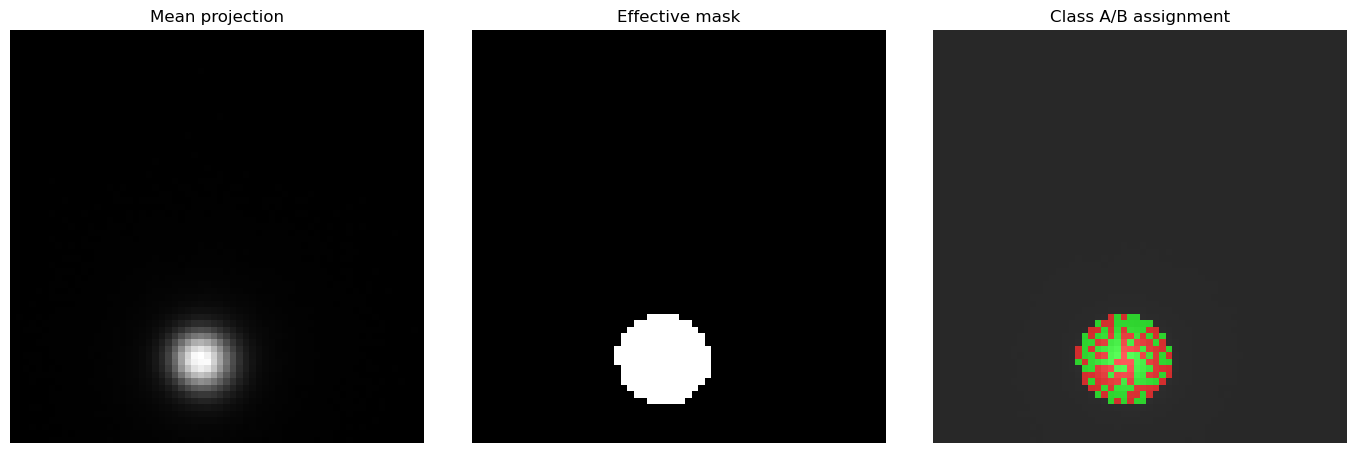

In [5]:
# =========================
# SINGLE RANDOM ASSIGNMENT
# =========================
single_assignment = assign_random_classes_from_mask(
    effective_mask=effective_mask,
    random_seed=BASE_RANDOM_SEED,
)

class_a_mask = single_assignment["class_a_mask"]
class_b_mask = single_assignment["class_b_mask"]

print(f"Total effective pixels: {single_assignment['n_pixels_total']}")
print(f"Class A pixels: {single_assignment['n_pixels_class_a']}")
print(f"Class B pixels: {single_assignment['n_pixels_class_b']}")

# =========================
# QC
# =========================
plot_class_assignment_qc(
    mean_projection=mean_projection,
    effective_mask=effective_mask,
    class_a_mask=class_a_mask,
    class_b_mask=class_b_mask,
)

## Compute COM time series and correlation for one class configuration

Masked traces shape: (48000, 163)
Selected frame intervals: [(0, 48000)]
Total selected frames: 48000
First selected frame: 0
Last selected frame: 47999
Single configuration correlation summary:
corr_x: 0.9956600070546936
corr_y: 0.8645483763558732
corr_mean_xy: 0.9301041917052835


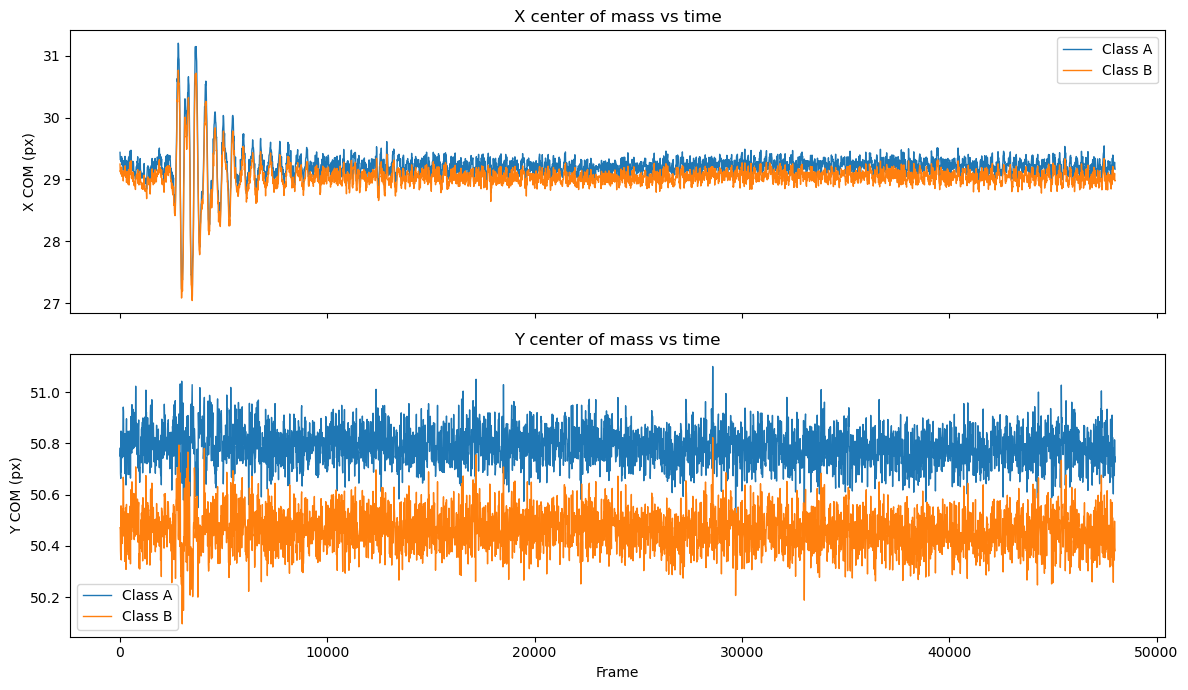

,frame,x_com,y_com,intensity_sum
0,0,29.436974,50.750763,32764.0
1,1,29.418381,50.738504,32425.0
2,2,29.370122,50.797561,31160.0
3,3,29.333568,50.738980,31262.0
4,4,29.326747,50.709039,30822.0


,frame,x_com,y_com,intensity_sum
0,0,29.247840,50.470602,33098.0
1,1,29.222575,50.461162,32726.0
2,2,29.201412,50.510077,31309.0
3,3,29.151083,50.438445,31817.0
4,4,29.110329,50.393884,31098.0


In [6]:
# =========================
# EXTRACT MASKED PIXEL TRACES
# =========================
masked_traces, mask_y, mask_x, frame_indices = extract_masked_pixel_traces(
    stack=stack,
    effective_mask=effective_mask,
    analysis_intervals=ANALYSIS_INTERVALS,
    chunk_size=COM_CHUNK_SIZE,
    output_dtype=np.float32,
)

print(f"Masked traces shape: {masked_traces.shape}")
print(f"Selected frame intervals: {ANALYSIS_INTERVALS}")
print(f"Total selected frames: {len(frame_indices)}")
print(f"First selected frame: {frame_indices[0]}")
print(f"Last selected frame: {frame_indices[-1]}")

# =========================
# COMPUTE COM SERIES
# =========================
com_a = compute_com_series_from_traces(
    masked_traces=masked_traces,
    mask_x=mask_x,
    mask_y=mask_y,
    class_selector=single_assignment["class_a_selector"],
    frame_indices=frame_indices,
)

com_b = compute_com_series_from_traces(
    masked_traces=masked_traces,
    mask_x=mask_x,
    mask_y=mask_y,
    class_selector=single_assignment["class_b_selector"],
    frame_indices=frame_indices,
)

# =========================
# CORRELATION
# =========================
single_corr_summary = compute_com_correlation_summary(com_a, com_b)

print("Single configuration correlation summary:")
for key, value in single_corr_summary.items():
    print(f"{key}: {value}")

# =========================
# QC PLOTS
# =========================
plot_com_series(
    com_a=com_a,
    com_b=com_b,
    analysis_intervals=ANALYSIS_INTERVALS,
    max_points_to_plot=MAX_POINTS_TO_PLOT,
)

display(com_a.head())
display(com_b.head())

## Iterative analysis with random class reassignments and average correlation

Completed iteration 1/100
Completed iteration 10/100
Completed iteration 20/100
Completed iteration 30/100
Completed iteration 40/100
Completed iteration 50/100
Completed iteration 60/100
Completed iteration 70/100
Completed iteration 80/100
Completed iteration 90/100
Completed iteration 100/100


,iteration,seed,n_pixels_class_a,n_pixels_class_b,corr_x,corr_y,corr_mean_xy
0,1,12345,81,82,0.995660,0.864548,0.930104
1,2,12346,81,82,0.992730,0.848504,0.920617
2,3,12347,81,82,0.995814,0.947653,0.971733
3,4,12348,81,82,0.992450,0.961017,0.976733
4,5,12349,81,82,0.982472,0.854443,0.918457


Final correlation summary across iterations:
Mean corr_x: 0.9922834687567291
Mean corr_y: 0.9014977081996632
Mean corr_mean_xy: 0.9468905884781961
Std corr_x: 0.005746010277350552
Std corr_y: 0.0762443576165803
Std corr_mean_xy: 0.03873454064351116


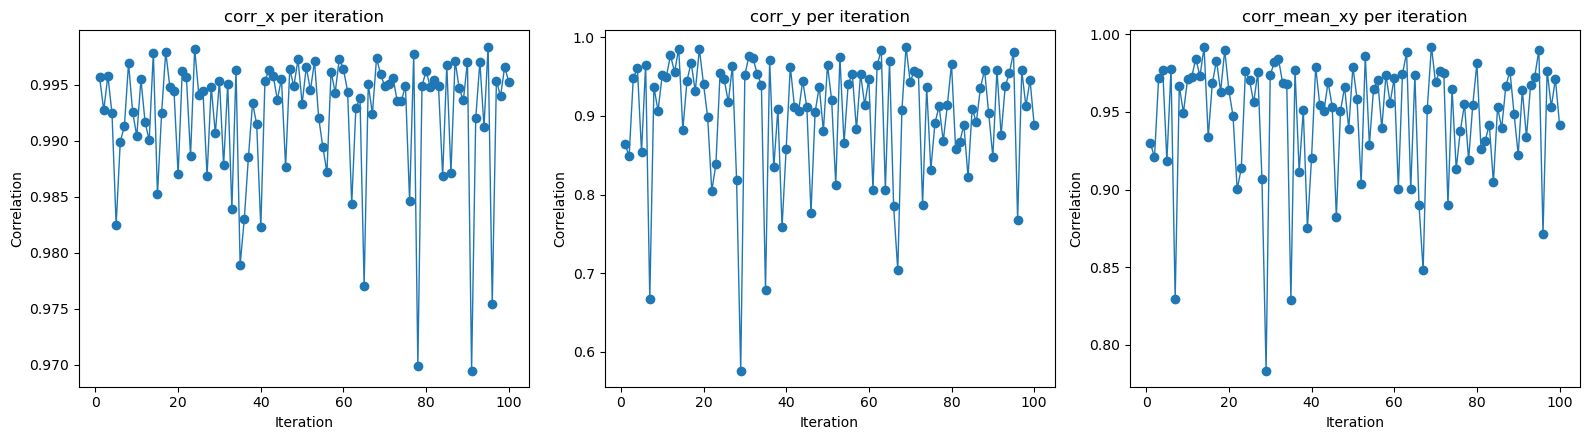

Results saved to: C:\Users\super\OneDrive\Desktop\Desktop1\20260210_Control2_Sphere_in_Vehicle_no_Fluos_a\COM_correlation_results


In [7]:
# =========================
# RUN ITERATIONS
# =========================
iteration_results = run_com_correlation_iterations(
    masked_traces=masked_traces,
    mask_x=mask_x,
    mask_y=mask_y,
    frame_indices=frame_indices,
    n_iterations=N_ITERATIONS,
    base_seed=BASE_RANDOM_SEED,
    report_every=10,
)

display(iteration_results.head())

# =========================
# FINAL SUMMARY
# =========================
mean_corr_x = iteration_results["corr_x"].mean()
mean_corr_y = iteration_results["corr_y"].mean()
mean_corr_xy = iteration_results["corr_mean_xy"].mean()

std_corr_x = iteration_results["corr_x"].std()
std_corr_y = iteration_results["corr_y"].std()
std_corr_xy = iteration_results["corr_mean_xy"].std()

print("Final correlation summary across iterations:")
print(f"Mean corr_x: {mean_corr_x}")
print(f"Mean corr_y: {mean_corr_y}")
print(f"Mean corr_mean_xy: {mean_corr_xy}")
print(f"Std corr_x: {std_corr_x}")
print(f"Std corr_y: {std_corr_y}")
print(f"Std corr_mean_xy: {std_corr_xy}")

# =========================
# VISUALIZATION
# =========================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(iteration_results["iteration"], iteration_results["corr_x"], marker="o", linewidth=1)
axes[0].set_title("corr_x per iteration")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Correlation")

axes[1].plot(iteration_results["iteration"], iteration_results["corr_y"], marker="o", linewidth=1)
axes[1].set_title("corr_y per iteration")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Correlation")

axes[2].plot(iteration_results["iteration"], iteration_results["corr_mean_xy"], marker="o", linewidth=1)
axes[2].set_title("corr_mean_xy per iteration")
axes[2].set_xlabel("Iteration")
axes[2].set_ylabel("Correlation")

plt.tight_layout()
plt.show()

# =========================
# OPTIONAL SAVE
# =========================
SAVE_RESULTS = True
OUTPUT_DIR = Path(selected_stack_path).parent / "COM_correlation_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if SAVE_RESULTS:
    com_a.to_csv(OUTPUT_DIR / "single_assignment_COM_A.csv", index=False)
    com_b.to_csv(OUTPUT_DIR / "single_assignment_COM_B.csv", index=False)
    iteration_results.to_csv(OUTPUT_DIR / "iteration_correlation_summary.csv", index=False)
    print(f"Results saved to: {OUTPUT_DIR}")